# QK plot

### import

In [5]:
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import japanize_matplotlib

### read data

In [2]:
# XMLファイルの読み込み
path_to_result = 'data/20250129plain.xml'
tree = ET.parse(path_to_result)
root = tree.getroot()

In [3]:
data_dict = {}
for data in root.findall('interval'):
    begin = data.get('begin')
    hour = int(float(begin)) // 3600  # 時間単位に変換
    id = data.get('id')
    n = float(data.get('flow'))
    v = float(data.get('speed')) * 3.6  # m/s → km/h に変換
    k = n / v if v != 0 else 0  # 密度計算 (k = Q/v)

    if id not in data_dict:
        data_dict[id] = {"flow": [], "vel": [], "k": [], "hour": []}

    data_dict[id]["flow"].append(n)
    data_dict[id]["vel"].append(v)
    data_dict[id]["k"].append(k)
    data_dict[id]["hour"].append(hour)

# 色マップの設定
cmap = cm.get_cmap('tab20', 24)  # 24時間対応のカラーマップ
norm = mcolors.Normalize(vmin=0, vmax=23)

/var/folders/7r/r8pvcqgd1_qfrjkk3c08zkj00000gn/T/ipykernel_91828/2919739123.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', 24)  # 24時間対応のカラーマップ


/var/folders/7r/r8pvcqgd1_qfrjkk3c08zkj00000gn/T/ipykernel_91828/3660994597.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


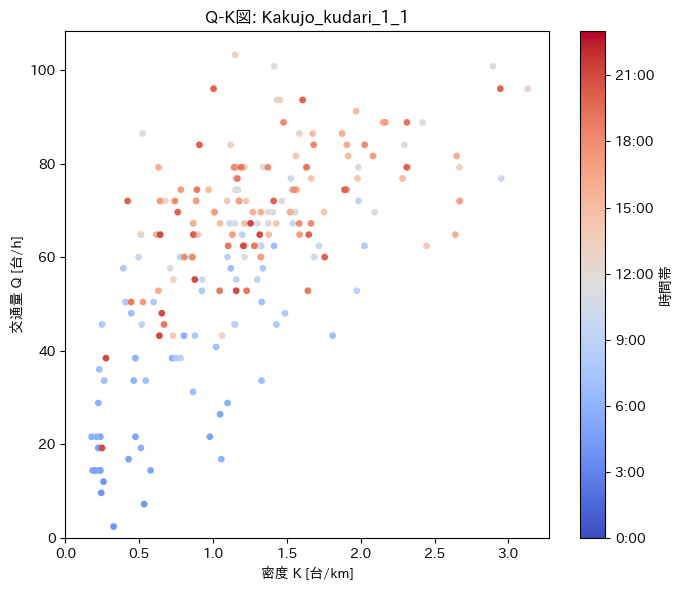

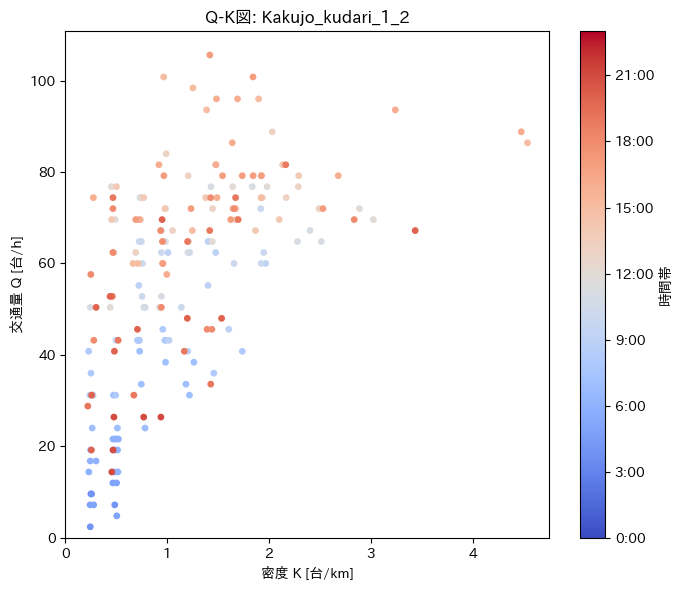

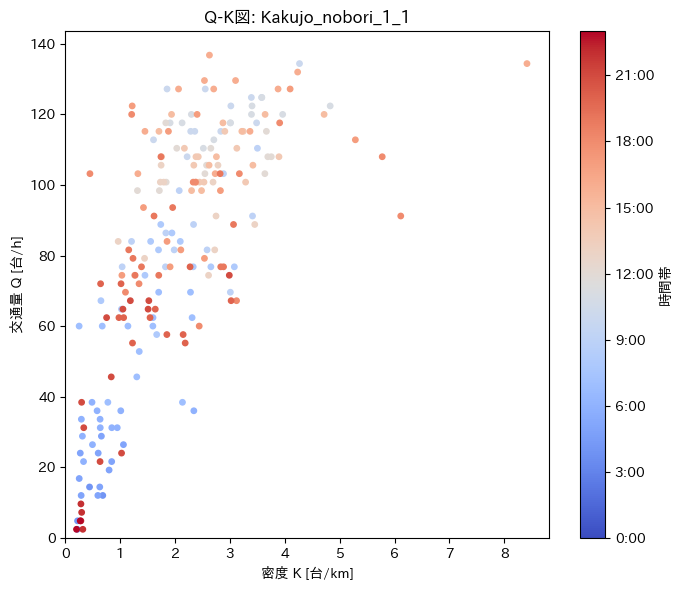

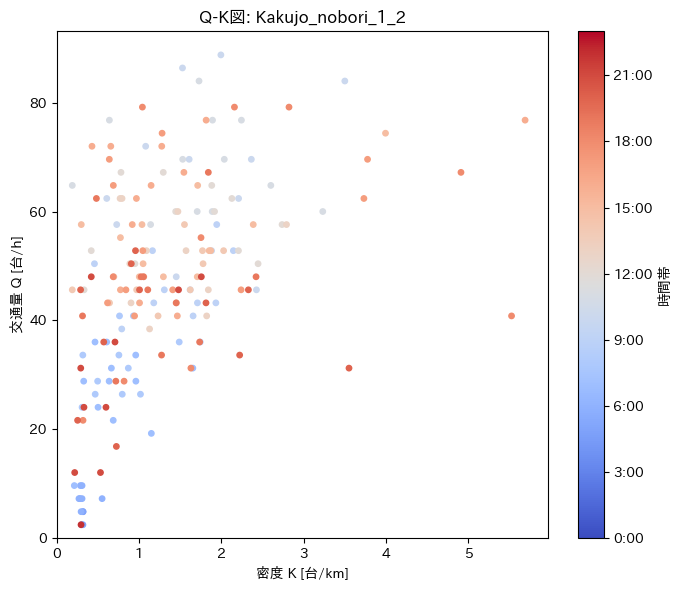

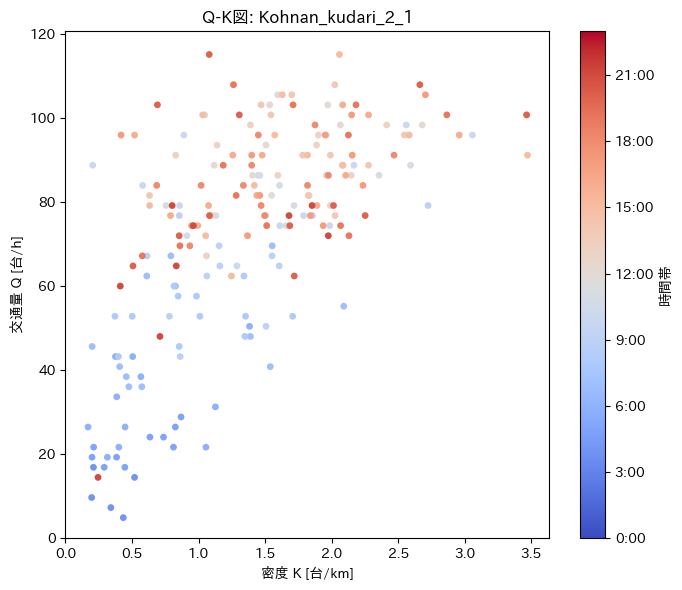

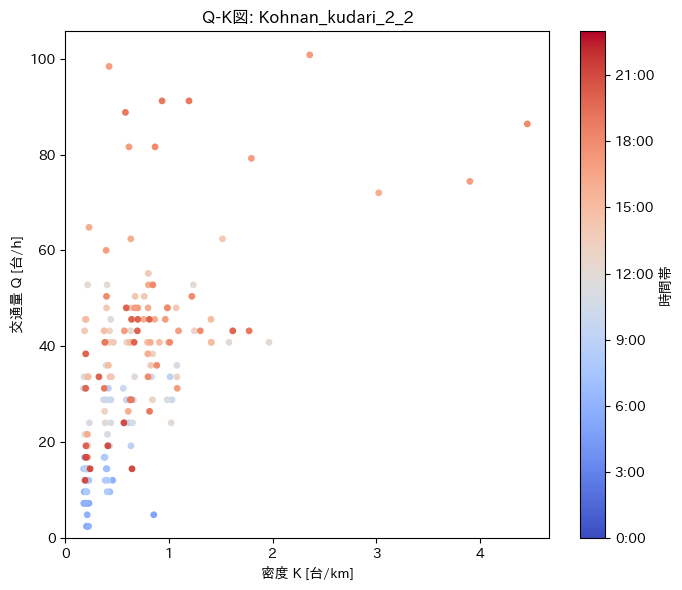

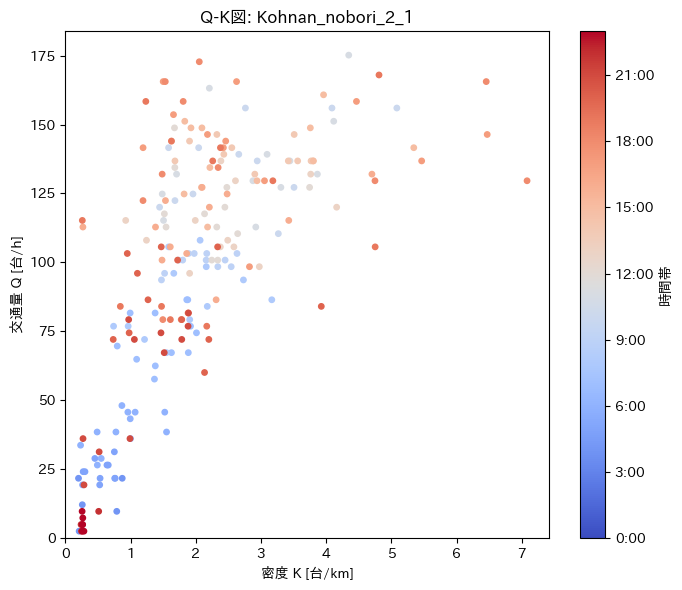

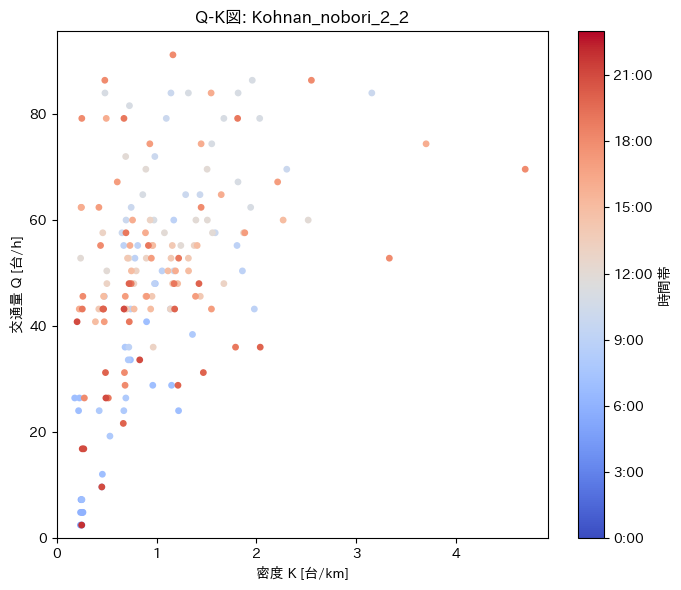

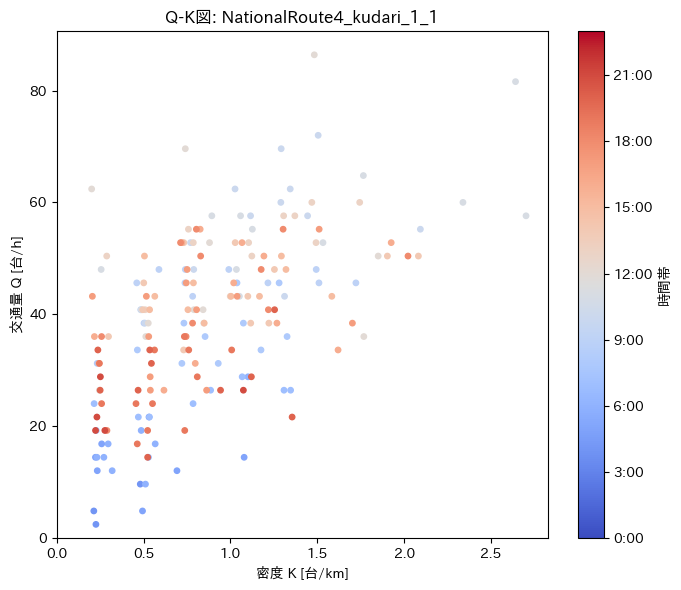

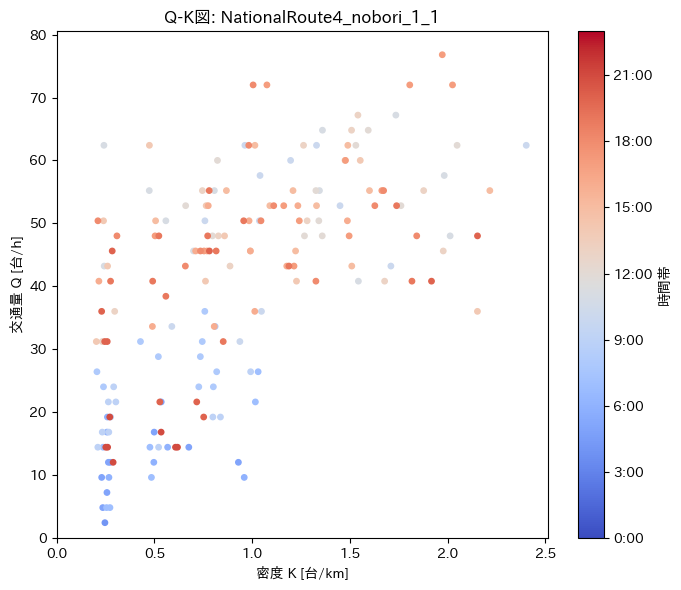

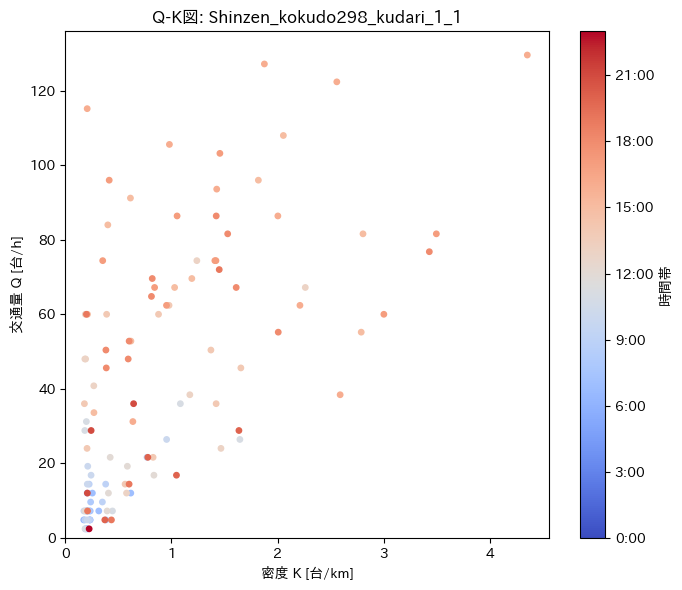

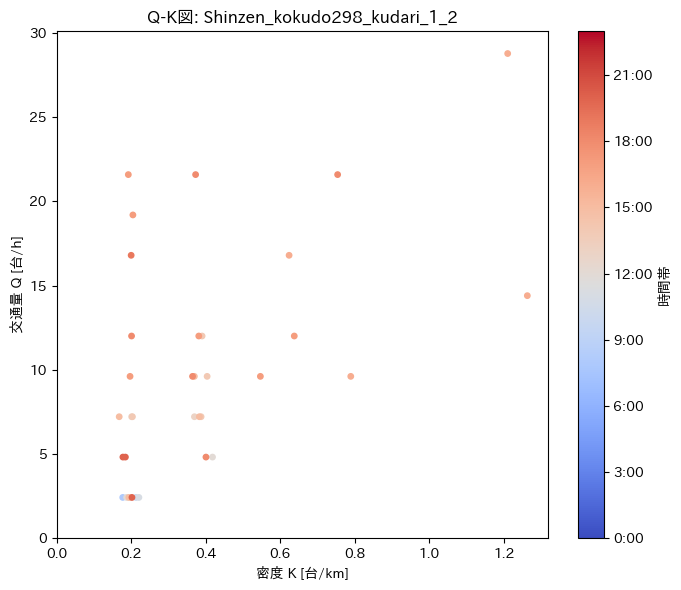

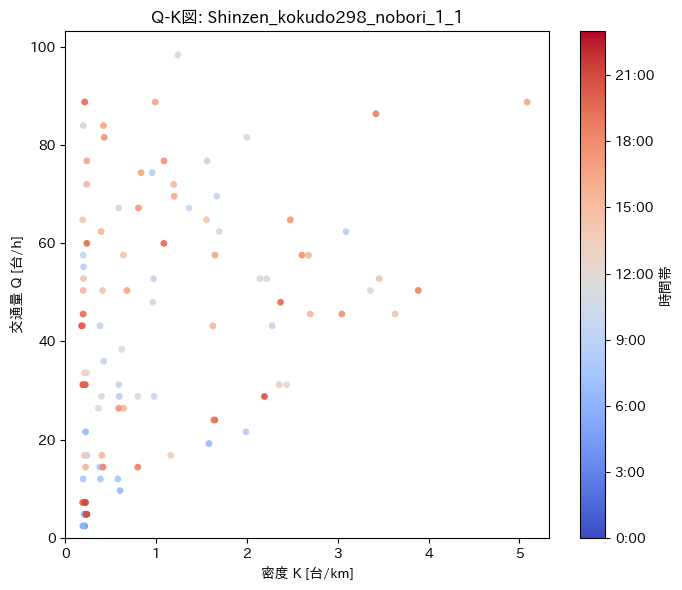

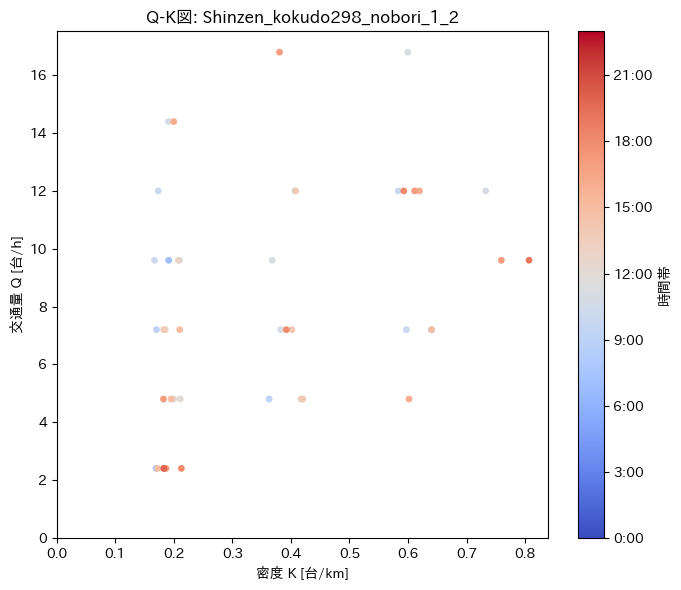

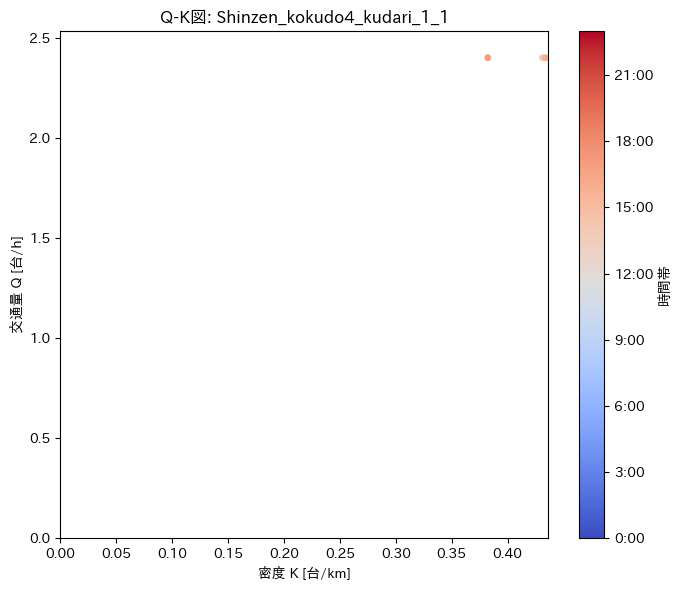

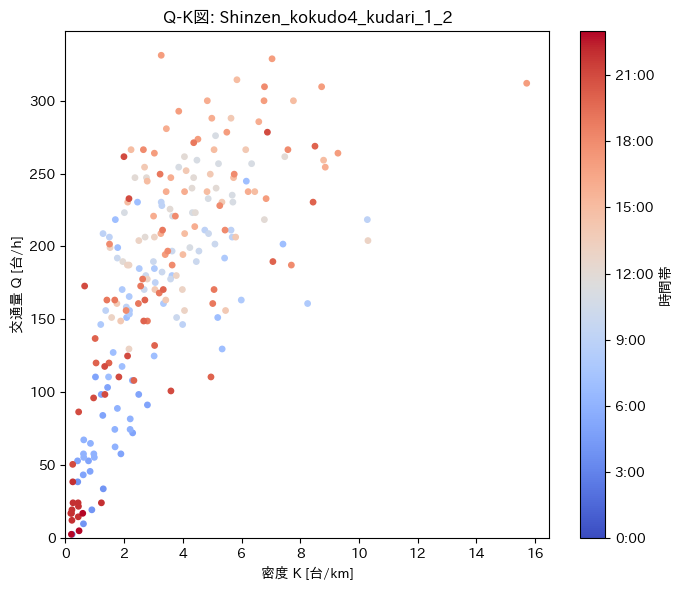

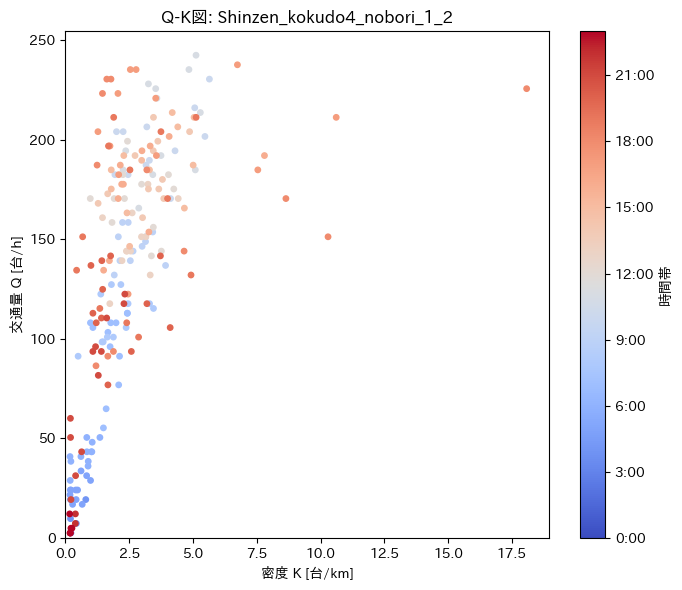

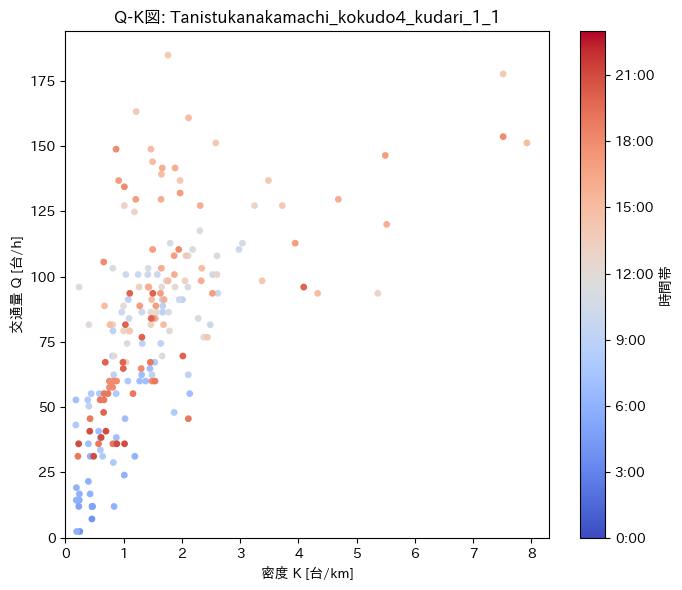

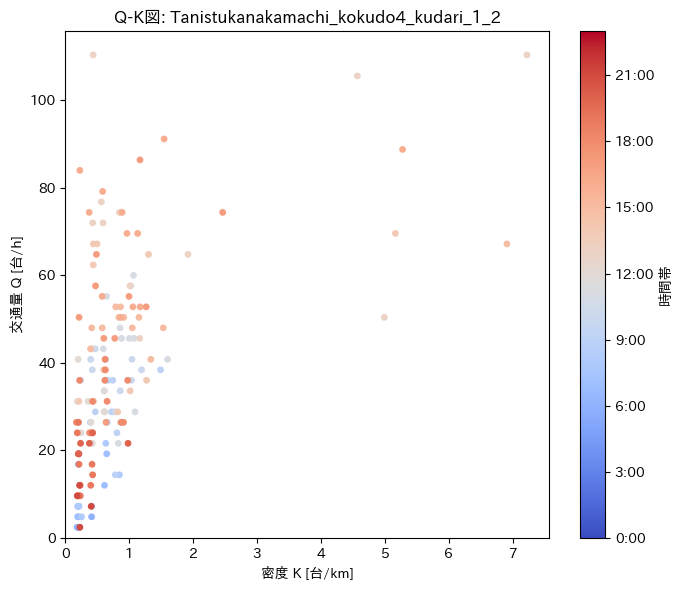

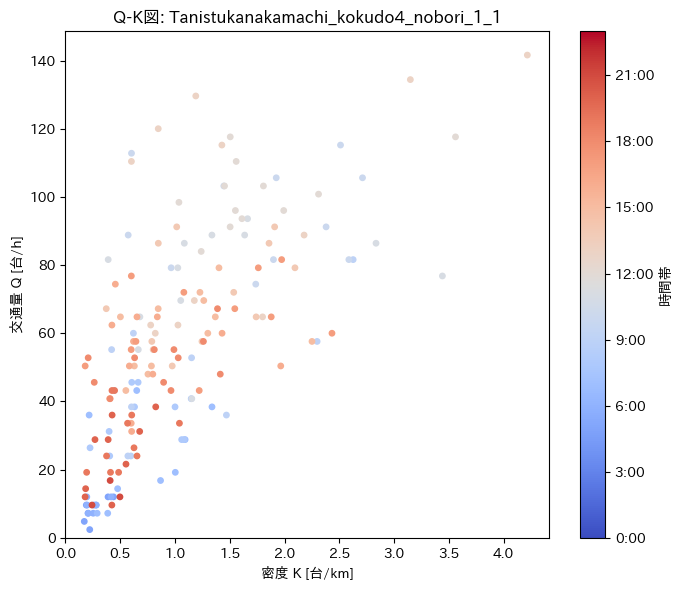

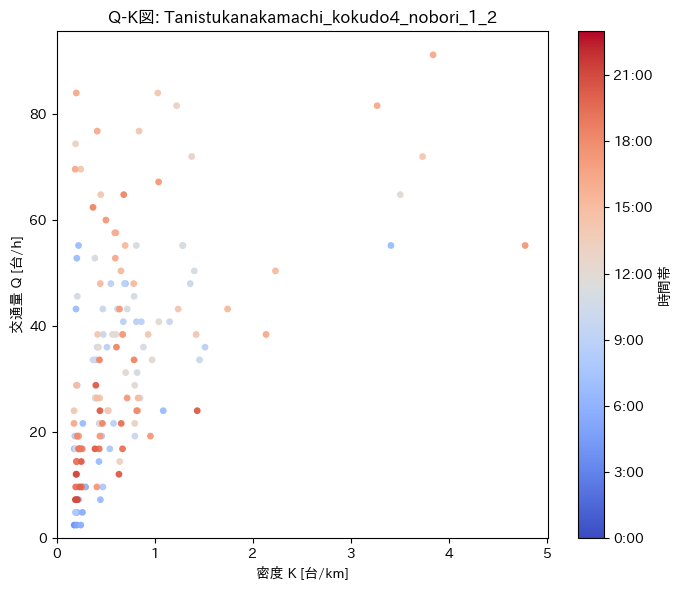

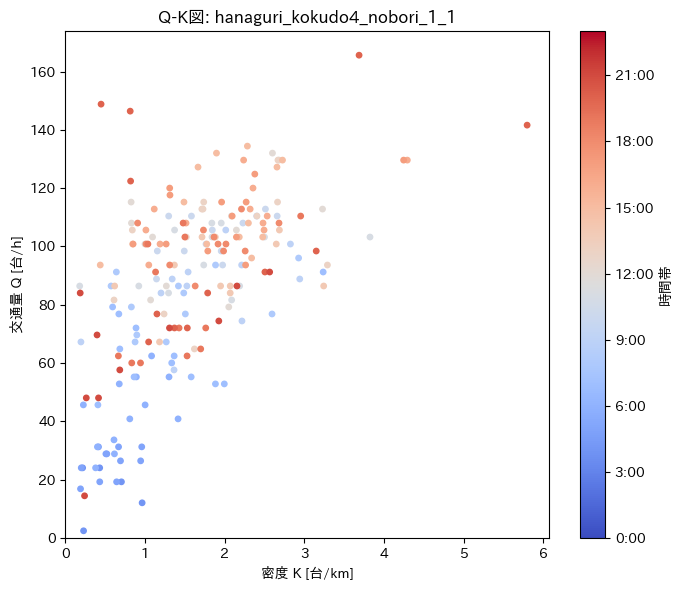

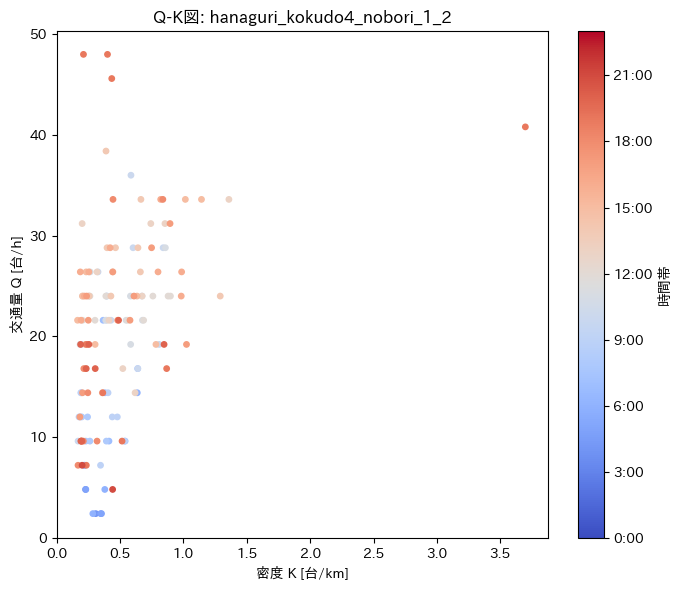

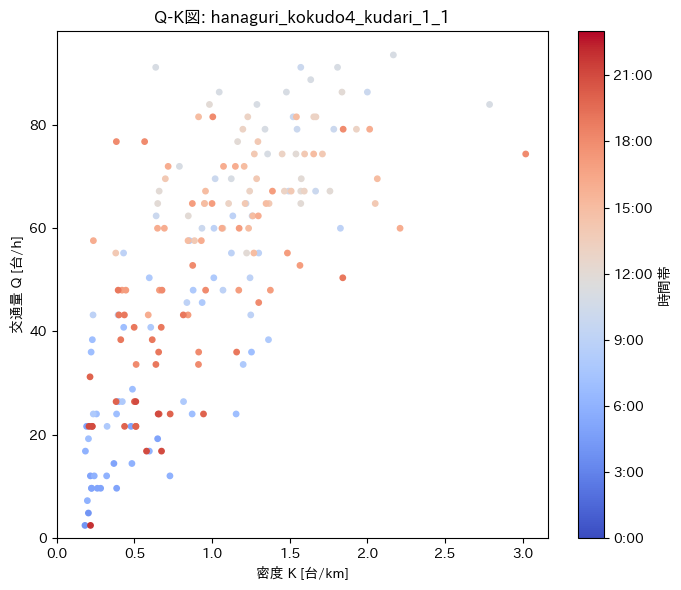

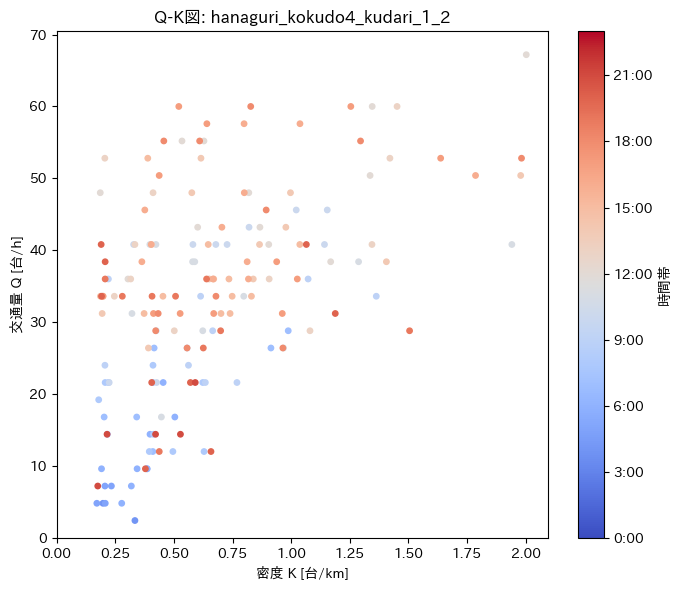

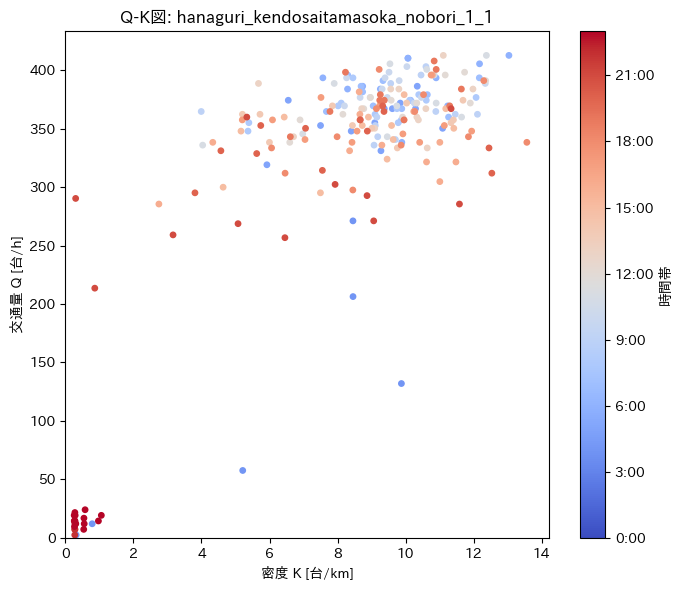

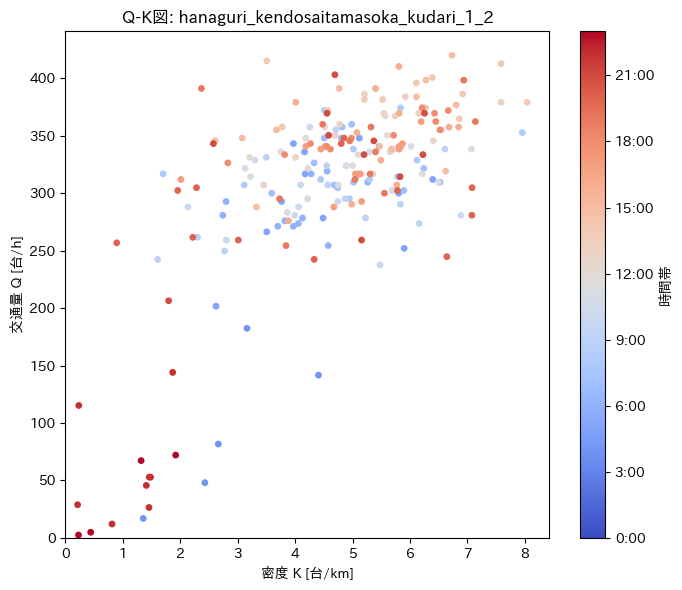

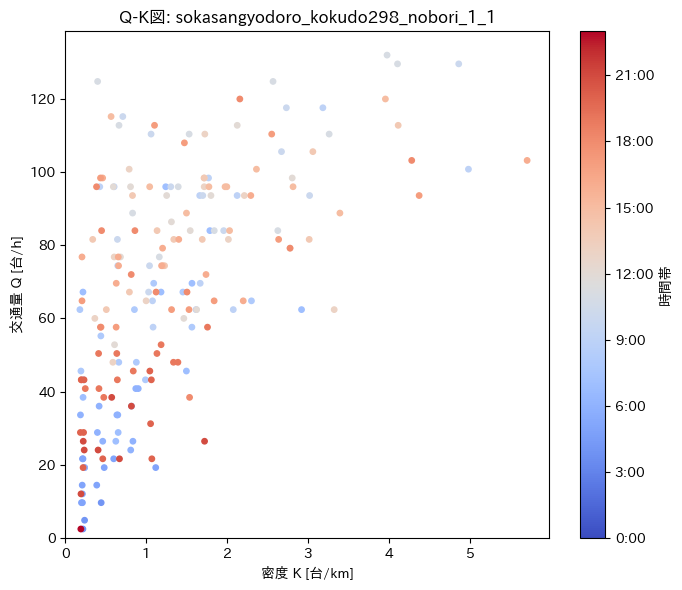

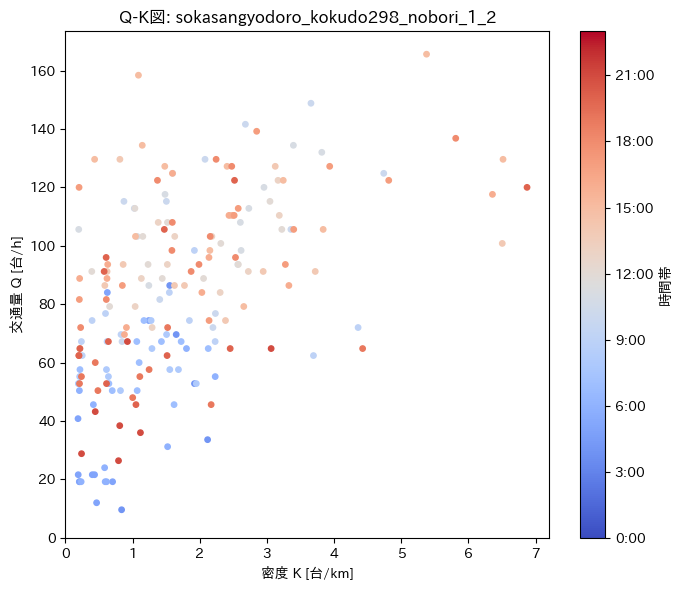

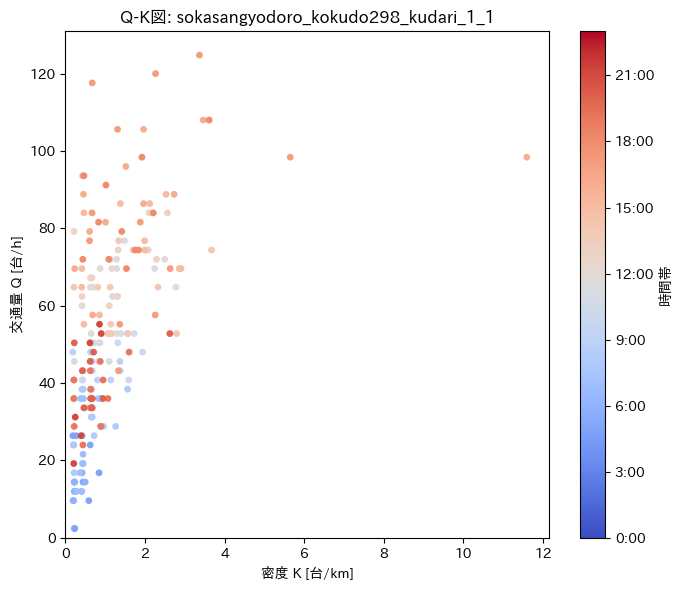

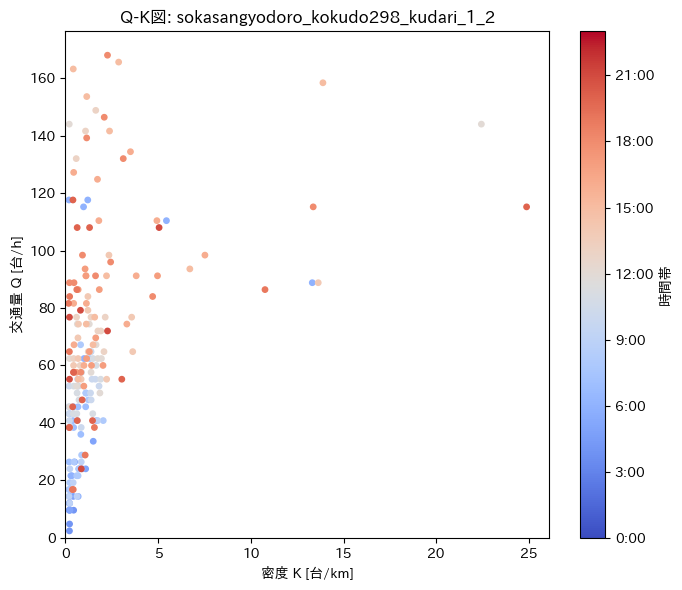

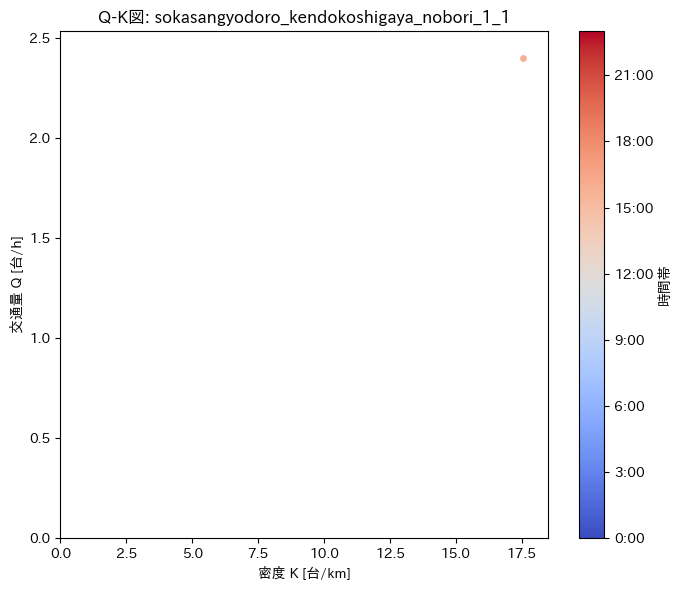

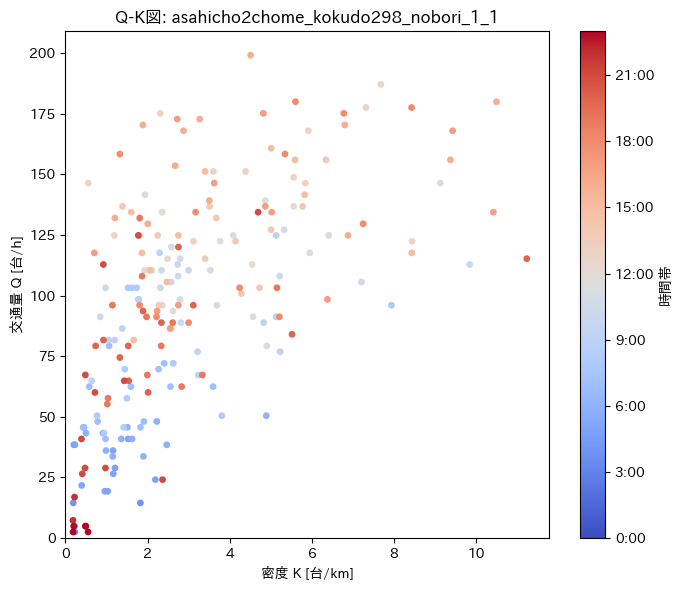

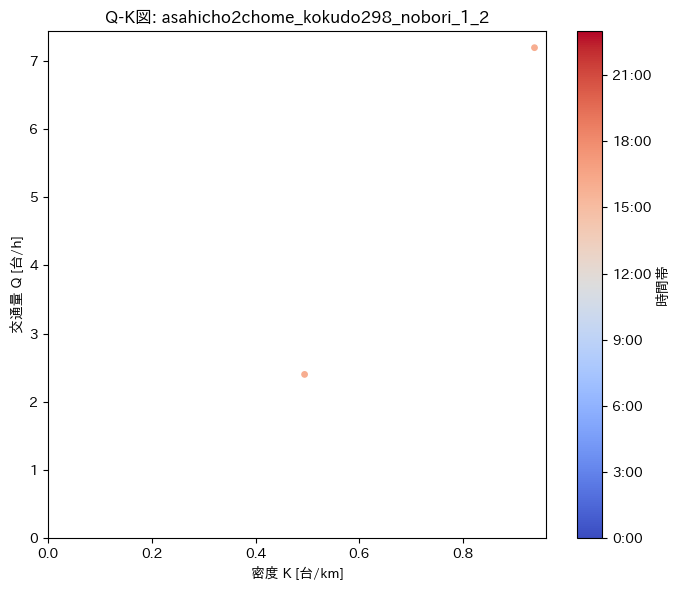

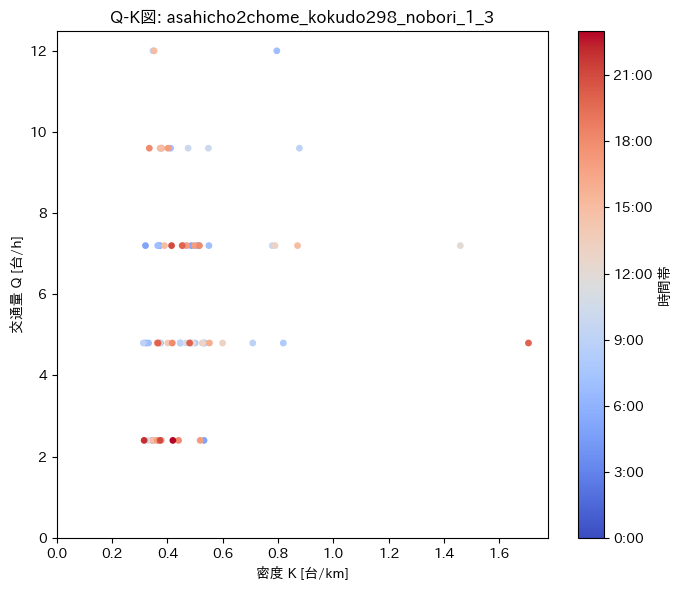

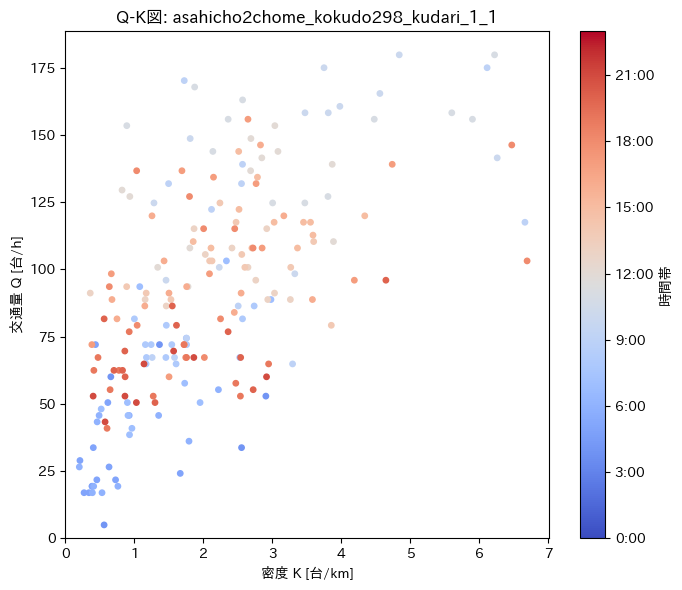

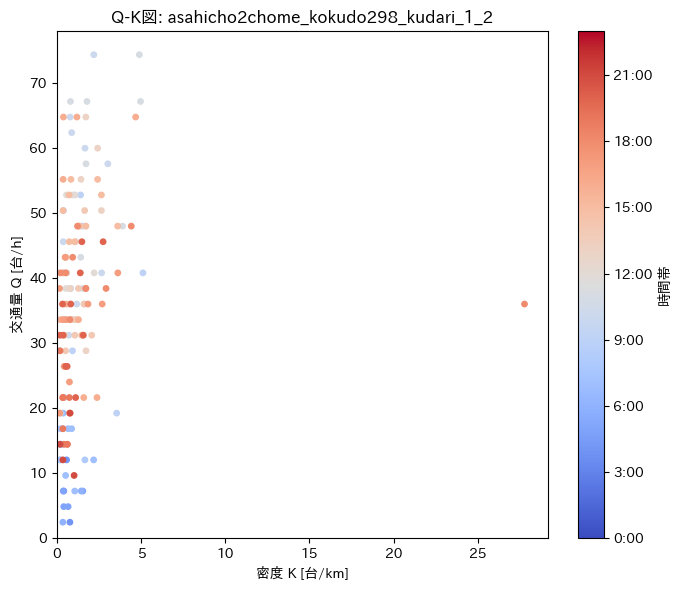

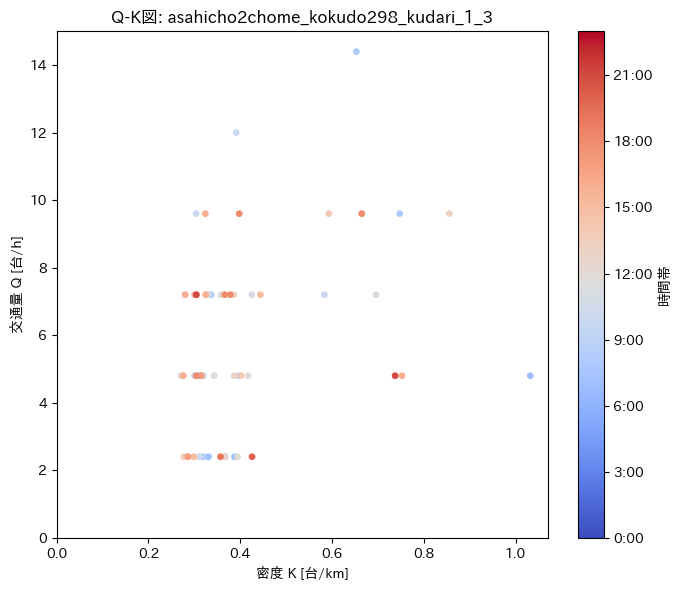

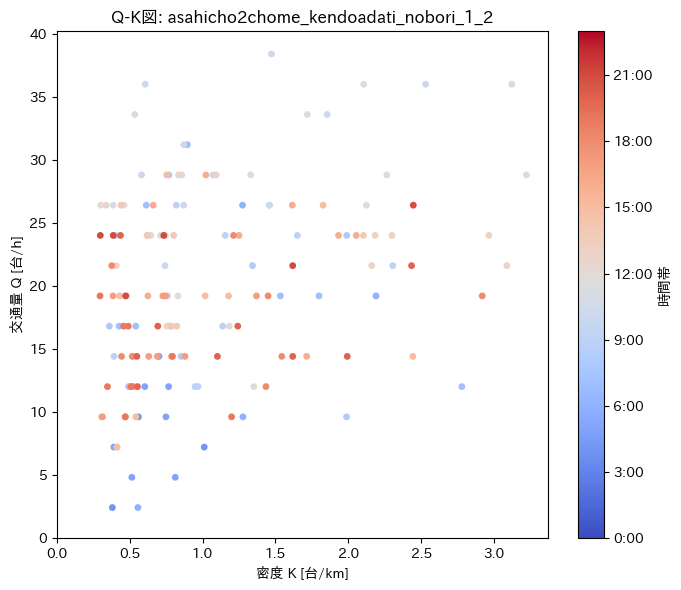

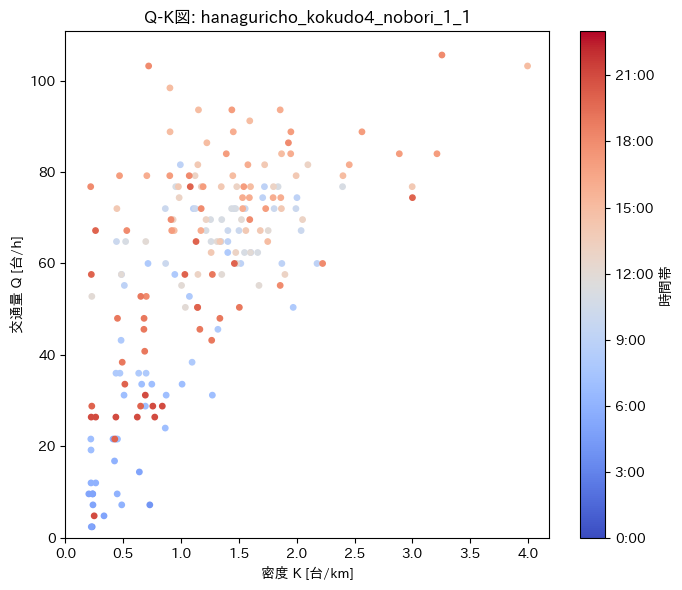

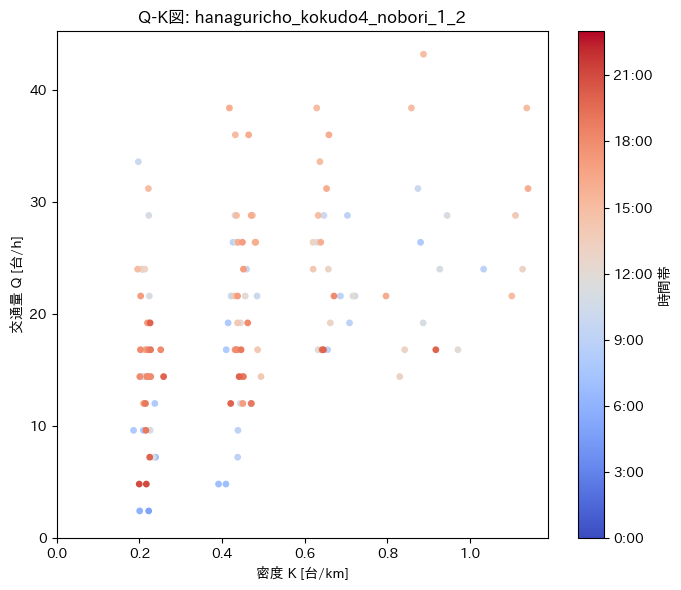

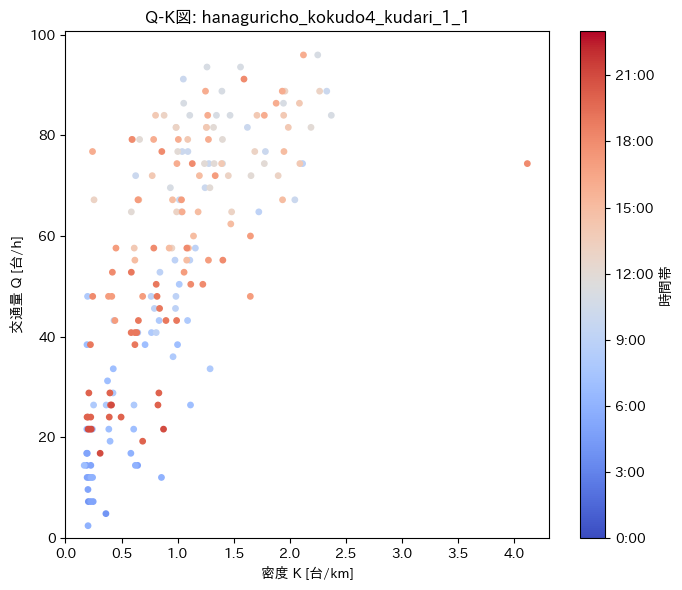

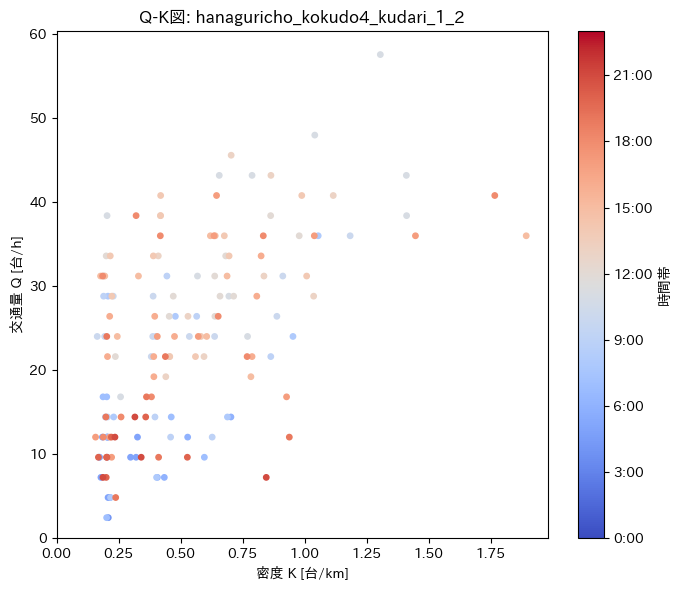

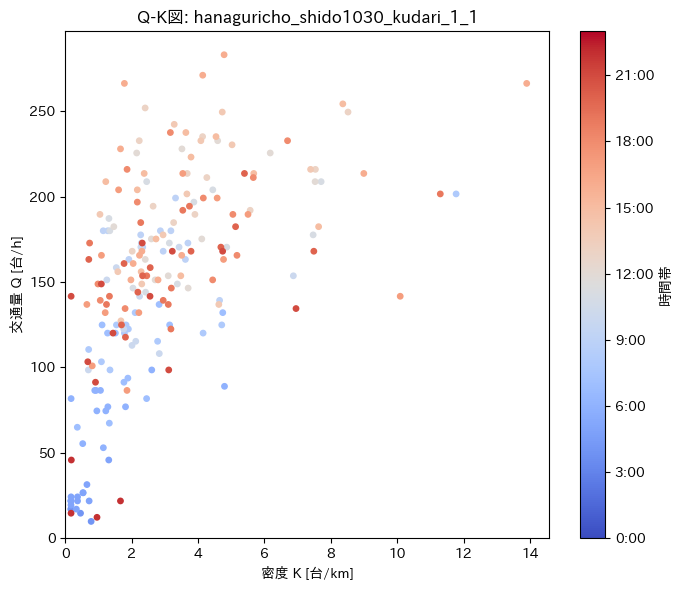

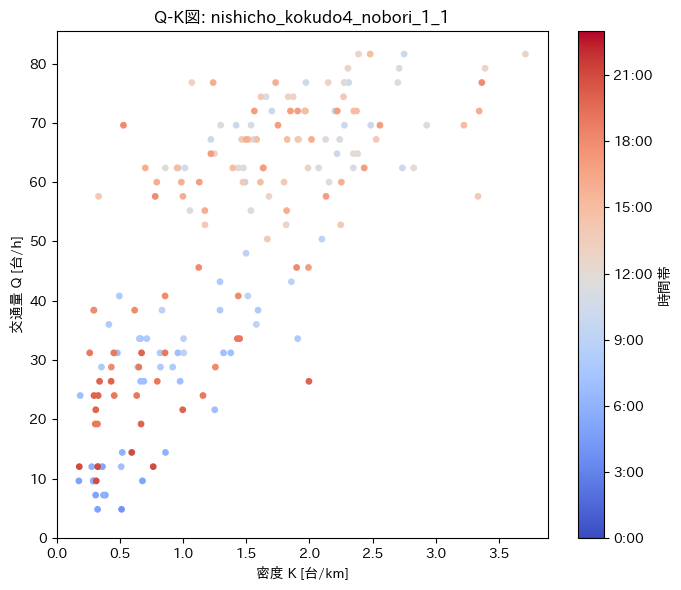

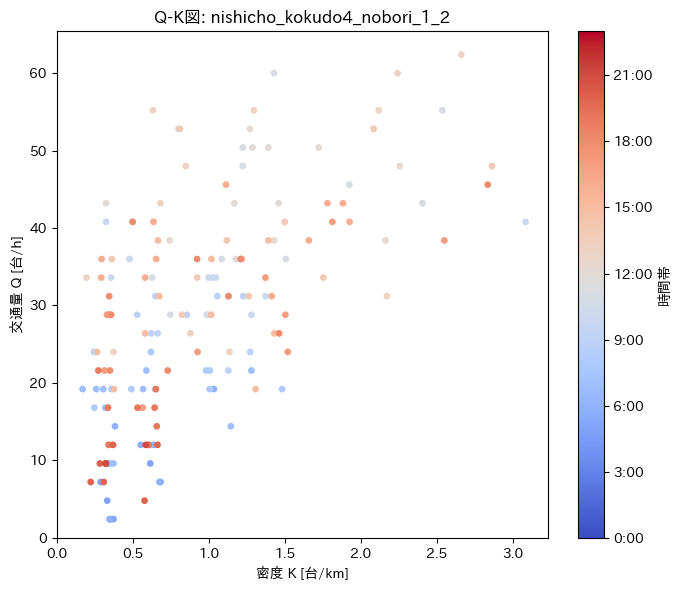

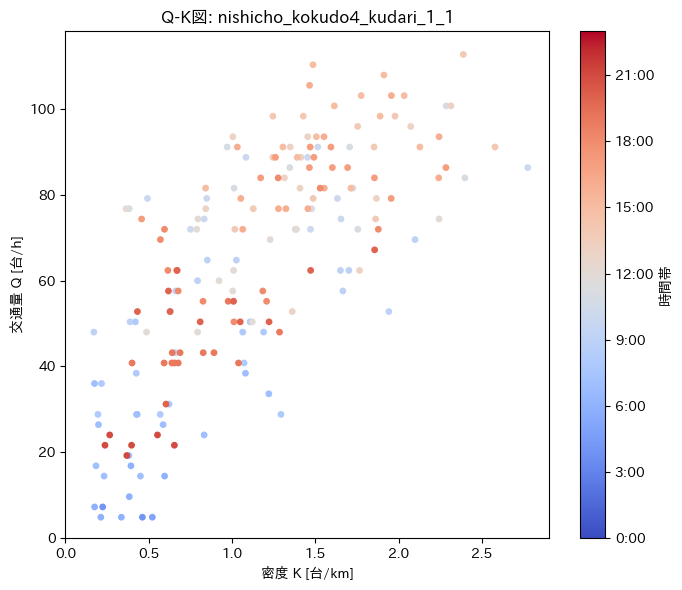

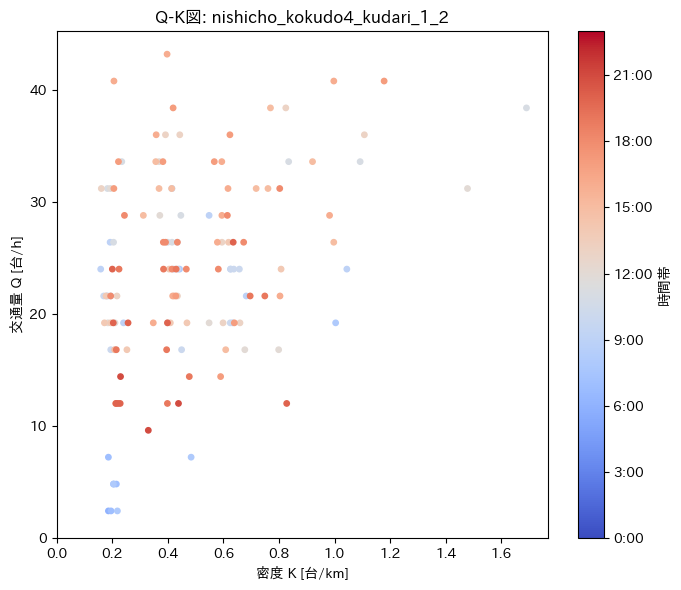

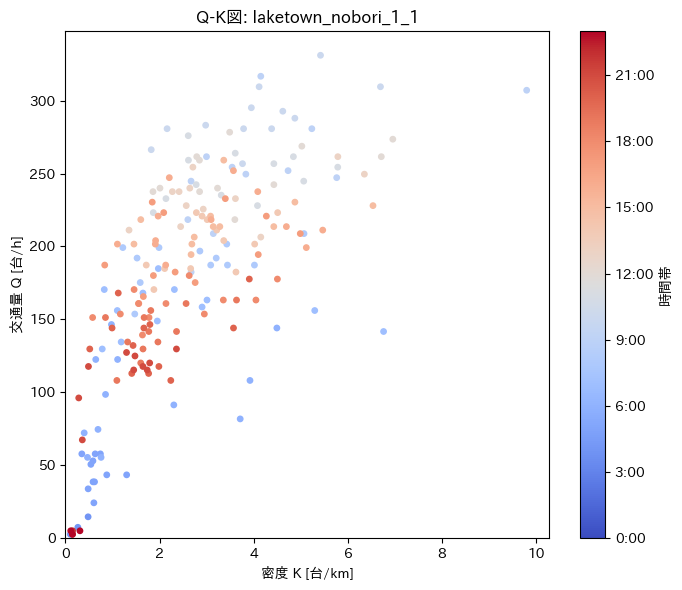

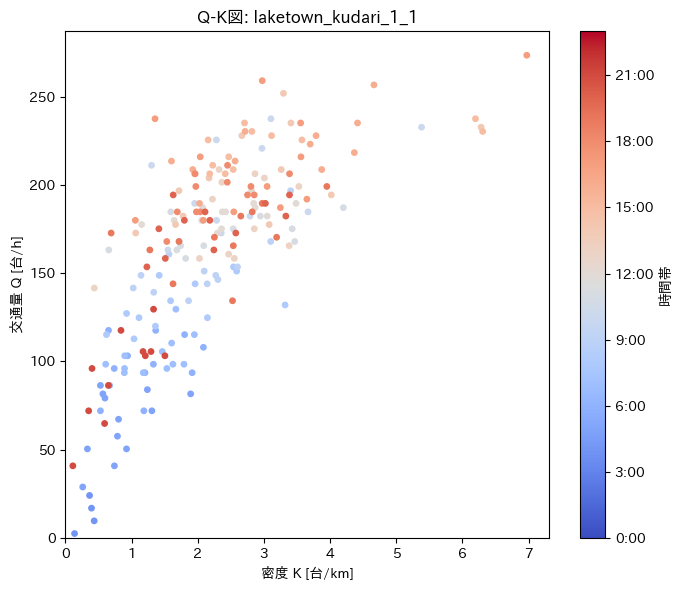

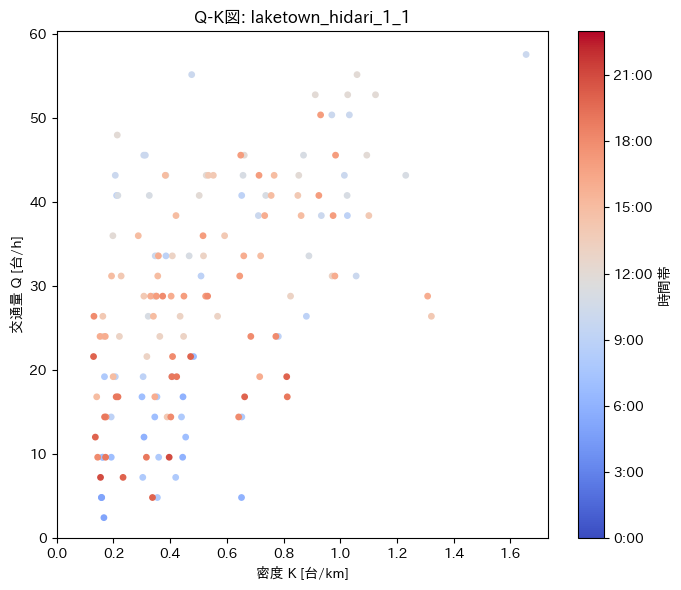

In [ ]:
# 暖色から寒色へのカラーマップ設定（早い時間→暖色、遅い時間→寒色）
cmap = cm.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=0, vmax=23)

# プロット処理
for key in data_dict:
    flow_series = pd.Series(data_dict[key]["flow"])
    flow_moving_avg = flow_series.rolling(window=5).mean()  # 移動平均計算
    k_series = pd.Series(data_dict[key]["k"])
    hours = pd.Series(data_dict[key]["hour"])

    # 有効な密度 (k > 0.01) のデータを抽出
    non_zero_indices = k_series > 0.01
    filtered_k = k_series[non_zero_indices]
    filtered_q = flow_moving_avg[non_zero_indices]
    filtered_hours = hours[non_zero_indices]

    if len(filtered_k) == 0:
        continue

    fig, ax = plt.subplots(figsize=(7, 6))

    # 時間ごとに色を変えて散布図を描画（暖色→寒色のグラデーション）
    scatter = ax.scatter(
        filtered_k,
        filtered_q,
        c=filtered_hours,
        cmap=cmap,
        norm=norm,
        s=15
    )

    ax.set_xlabel("密度 K [台/km]")
    ax.set_ylabel("交通量 Q [台/h]")
    ax.set_xlim(0, None)
    ax.set_ylim(0, None)
    ax.set_title(f"Q-K図: {key}")

    # カラーバー追加（時間帯の目安として表示）
    cbar = plt.colorbar(scatter, ax=ax, ticks=range(0, 24, 3))
    cbar.set_label("時間帯")s
    cbar.set_ticks(range(0, 24, 3))
    cbar.set_ticklabels([f"{hour}:00" for hour in range(0, 24, 3)])

    plt.tight_layout()
    plt.show()

    if key ==  "kakujo_nobori_1_1":
        break
